In [4]:
import gymnasium as gym

# Initialise the environment
env = gym.make("CartPole-v1", render_mode="human")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)
for _ in range(1000):
    # this is where you would insert your policyq
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

env.close()

**Description**

Deep Q-Network agent is being trained to solve the CartPole balancing problem. The neural network takes in four continuous state values (position, velocity, angle, angular velocity) and outputs Q-values for the two actions (left, right). The agent learns through experience replay and a target network to stabilize learning. Over time, it learns to balance the pole by predicting which action maximizes long-term reward.

# Create a DQN Agent

In [5]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import random
from tqdm import trange
import matplotlib.pyplot as plt

In [6]:
# --- Q-network ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Replay Buffer ---
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        s, a, r, ns, d = zip(*random.sample(self.buffer, batch_size))
        return (
            torch.FloatTensor(s),
            torch.LongTensor(a),
            torch.FloatTensor(r),
            torch.FloatTensor(ns),
            torch.FloatTensor(d)
        )

    def __len__(self):
        return len(self.buffer)

# --- DQN Agent ---
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.q_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=1e-3)
        self.replay_buffer = ReplayBuffer()
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995
        self.batch_size = 64

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(action_dim)
        state = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            return torch.argmax(self.q_net(state)).item()

    def update(self):
        if len(self.replay_buffer) < self.batch_size:
            return

        s, a, r, ns, d = self.replay_buffer.sample(self.batch_size)
        q_values = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        next_q_values = self.target_net(ns).max(1)[0]
        expected_q = r + self.gamma * next_q_values * (1 - d)

        loss = nn.MSELoss()(q_values, expected_q.detach())
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

## Training

In [7]:
# --- Training ---
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DQNAgent(state_dim, action_dim)

episodes = 200
rewards = []

for ep in trange(episodes, desc="Training DQN on CartPole"):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        agent.replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        agent.update()

    agent.update_target()
    agent.decay_epsilon()
    rewards.append(total_reward)

    if ep % 20 == 0:
        print(f"Episode {ep}, Reward: {total_reward:.1f}, Epsilon: {agent.epsilon:.2f}")

env.close()

Training DQN on CartPole:   0%|                         | 0/200 [00:00<?, ?it/s]/tmp/ipykernel_20385/2243245021.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  torch.FloatTensor(s),
Training DQN on CartPole:   2%|▎                | 3/200 [00:00<00:08, 24.34it/s]

Episode 0, Reward: 20.0, Epsilon: 0.99


Training DQN on CartPole:  10%|█▋              | 21/200 [00:01<00:15, 11.75it/s]

Episode 20, Reward: 26.0, Epsilon: 0.90


Training DQN on CartPole:  20%|███▎            | 41/200 [00:03<00:13, 12.20it/s]

...

Training DQN on CartPole:  80%|████████████   | 161/200 [00:34<00:14,  2.68it/s]

Episode 160, Reward: 63.0, Epsilon: 0.45


Training DQN on CartPole:  90%|█████████████▌ | 181/200 [00:43<00:06,  2.77it/s]

Episode 180, Reward: 90.0, Epsilon: 0.40


Training DQN on CartPole: 100%|███████████████| 200/200 [00:52<00:00,  3.80it/s]


# Improvement visualization (plotting rewards)

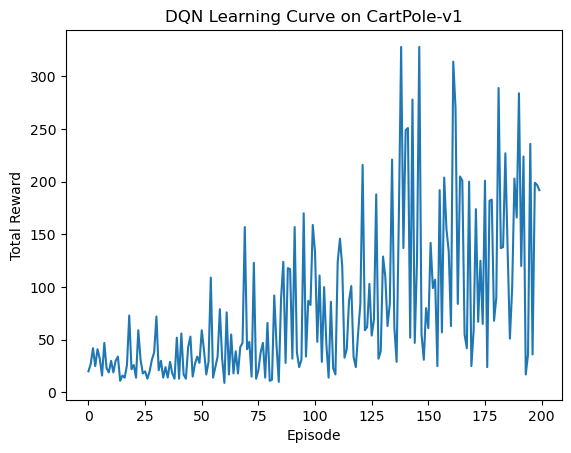

In [8]:
# --- Plot learning curve ---
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Learning Curve on CartPole-v1")
plt.show()

# Demo (running the trained agent)

In [9]:
env = gym.make("CartPole-v1", render_mode="human")
state, _ = env.reset()
done = False
while not done:
    action = agent.select_action(state)
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
env.close()
